# hMOF Hydrogen Storage: Modelling Notebook

Built on the findings of the dataset deep dive:

| Decision | Reason |
|---|---|
| **3 targets**: uptake at 77 K / 2 bar, 77 K / 100 bar, and deliverable capacity (100 − 2 bar) | Only these two conditions exist; DC is the storage-relevant metric |
| **Label cleaning**: drop accessible MOFs (PLD ≥ 3.2 Å) below 50% of the bulk-H₂ floor, and DC < −1 g/L | ~150 physically inconsistent labels, mostly batch hMOF-3001xxx |
| **Two-stage pipeline**: zero/non-zero classifier, then regression | 3,114 zeros come from pores too narrow for H₂ |
| **3 splits**: random, building-block grouped (MOFkey), leave-topology-out | Random splits overestimate performance on near-duplicates |
| **Models**: XGBoost (geometry), XGBoost (geometry + composition), GNN (graph only), GNN (graph + global descriptors) | Ablation shows what the graph adds beyond pore geometry |

**Run on Kaggle with GPU and Internet on.** Graph featurization is cached in `/kaggle/working/model/graph_chunks`. After one full run, use *Save Version*, then attach this notebook's output as an input in later sessions: the cache is found automatically and featurization is skipped.

Outputs for the RASPA notebook are written at the end (`raspa_targets.csv`).

## 1. Configuration

In [2]:
import os, glob

SEED = 42
DATA_URL = ("https://mof.tech.northwestern.edu/Datasets/"
            "hMOF-10%201021%20acs%20jpcc%206b08729-Hydrogen-mofdb-version:dc8a0295db.zip")
ZIP_PATH = "/tmp/data.zip"
RAW_DIR = "/tmp/hMOF_data"
WORK_DIR = "/kaggle/working/model" if os.path.isdir("/kaggle/working") else "./model_outputs"
os.makedirs(WORK_DIR, exist_ok=True)

# Reuse cached graphs if this notebook's earlier output is attached as an input
cache_candidates = sorted(glob.glob("/kaggle/input/**/graph_chunks", recursive=True))
cache_candidates = [c for c in cache_candidates if glob.glob(os.path.join(c, "chunk_*.pt"))]
GRAPH_DIR = cache_candidates[0] if cache_candidates else os.path.join(WORK_DIR, "graph_chunks")
os.makedirs(GRAPH_DIR, exist_ok=True)
print("Graph cache:", GRAPH_DIR)

NEIGHBOR_CUTOFF = 4.5
CHUNK_SIZE = 5000

# Label cleaning (from the EDA)
ACCESSIBLE_PLD = 3.2       # Angstrom
FLOOR_FRAC = 0.5           # flag if 100-bar uptake < 50% of void_fraction x bulk H2 density
DC_NEG_LIMIT = -1.0        # flag if deliverable capacity < -1 g/L

TARGETS = ["y2", "y100", "dc"]
TARGET_NAMES = {"y2": "77 K / 2 bar", "y100": "77 K / 100 bar", "dc": "Deliverable (100-2 bar)"}
GEO = ["void_fraction", "surface_area_m2g", "surface_area_m2cm3", "lcd", "pld"]
GLOBALS = GEO + ["density"]            # inputs for the GNN global branch
SPLITS = ["random", "building_block", "topology"]

# GNN training
EPOCHS = 40
PATIENCE = 8
LR = 1e-3
WEIGHT_DECAY = 1e-5
BATCH_PER_GPU = 64
GNN_RUNS = [("full", "random"), ("graph_only", "random"),
            ("full", "building_block"), ("full", "topology")]
N_ENSEMBLE = 3             # extra seeds of the full model on the random split (uncertainty)

Graph cache: /kaggle/working/model/graph_chunks


## 2. Setup

In [3]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pymatgen", "torch_geometric", "CoolProp"], check=True)

import json, random, time, gc, zipfile, warnings
from multiprocessing import Pool, cpu_count
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import xgboost as xgb
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                             accuracy_score, precision_score, recall_score)

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)

def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
seed_everything()

NUM_GPUS = torch.cuda.device_count()
MULTI_GPU = NUM_GPUS > 1
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
XGB_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"GPUs: {NUM_GPUS} | torch {torch.__version__} | xgboost {xgb.__version__}")

def savefig(name):
    plt.tight_layout(); plt.savefig(os.path.join(WORK_DIR, name), dpi=150); plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.8/825.8 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.9 MB/s eta 0:00:00
GPUs: 2 | torch 2.11.0+cu128 | xgboost 3.4.1


## 3. Load labels and geometric descriptors from the JSON files

In [17]:
import shutil
EXPECTED = 137953

json_index = index_files(RAW_DIR, ".json") if os.path.isdir(RAW_DIR) else {}
if len(json_index) < EXPECTED:
    print(f"Only {len(json_index)} JSON files found; re-extracting from scratch.")
    shutil.rmtree(RAW_DIR, ignore_errors=True)
    if not (os.path.exists(ZIP_PATH) and zipfile.is_zipfile(ZIP_PATH)):
        download_zip()
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(RAW_DIR)
    json_index = index_files(RAW_DIR, ".json")
cif_index = index_files(RAW_DIR, ".cif")
print(f"JSON: {len(json_index)} | CIF: {len(cif_index)}")
assert len(json_index) == EXPECTED and len(cif_index) == EXPECTED, "Dataset incomplete"

Only 60337 JSON files found; re-extracting from scratch.
JSON: 137953 | CIF: 137953


In [29]:
import shutil
EXPECTED = 137953

print("Before:", "df rows =", len(df) if "df" in globals() else None,
      "| JSON =", len(json_index), "| CIF =", len(cif_index))

json_index = index_files(RAW_DIR, ".json") if os.path.isdir(RAW_DIR) else {}
if len(json_index) < EXPECTED:
    print("Incomplete data -> deleting and re-extracting...")
    shutil.rmtree(RAW_DIR, ignore_errors=True)
    if not (os.path.exists(ZIP_PATH) and zipfile.is_zipfile(ZIP_PATH)):
        download_zip()
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(RAW_DIR)
    json_index = index_files(RAW_DIR, ".json")
cif_index = index_files(RAW_DIR, ".cif")
print("Files: JSON =", len(json_index), "| CIF =", len(cif_index))
assert len(json_index) == EXPECTED and len(cif_index) == EXPECTED, "Dataset still incomplete"

names = sorted(set(json_index) & set(cif_index))
with Pool(cpu_count()) as pool:
    recs = [r for r in tqdm(pool.imap(parse, names, chunksize=500), total=len(names)) if r]
df = pd.DataFrame(recs).dropna(subset=["y2", "y100"]).sort_values("name").reset_index(drop=True)
for c in GEO + ["y2", "y100"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
print("After: df rows =", len(df))
assert len(df) == EXPECTED, "df is still incomplete"

Before: df rows = 60336 | JSON = 137953 | CIF = 137953
Files: JSON = 137953 | CIF = 137953


  0%|          | 0/137953 [00:00<?, ?it/s]

After: df rows = 137953


## 4. Label cleaning, targets, and the zero class

In [30]:
from CoolProp.CoolProp import PropsSI
RHO_BULK_100 = PropsSI("D", "T", 77, "P", 100e5, "Hydrogen")    # g/L
print(f"Bulk H2 density at 77 K, 100 bar: {RHO_BULK_100:.1f} g/L")

df["dc_raw"] = df.y100 - df.y2
floor = df.void_fraction * RHO_BULK_100
df["ratio_floor"] = np.where(floor > 0, df.y100 / floor, np.nan)
df["accessible"] = df.pld >= ACCESSIBLE_PLD
df["flag_floor"] = df.accessible & (df.ratio_floor < FLOOR_FRAC)
df["flag_dc"] = df.dc_raw < DC_NEG_LIMIT
df["flag"] = df.flag_floor | df.flag_dc
df["dc"] = df.dc_raw.clip(lower=0.0)          # remaining small negatives (-1, 0] are noise
df["is_zero"] = df.y100 == 0
df["id_block"] = df.name.str.extract(r"hMOF-(\d+)", expand=False).astype(int) // 1000

print(f"Flagged: floor {df.flag_floor.sum()} | DC {df.flag_dc.sum()} | total {df.flag.sum()} "
      f"({df.flag.mean():.2%})")
print("Flagged by ID block:\n", df[df.flag].id_block.value_counts().head(6).to_string())
print(f"Zero-uptake MOFs: {df.is_zero.sum()} ({df.is_zero.mean():.2%})")
df.loc[df.flag, ["name", "void_fraction", "pld", "lcd", "y2", "y100", "dc_raw", "flag_floor", "flag_dc"]] \
  .to_csv(os.path.join(WORK_DIR, "flagged_labels.csv"), index=False)

Bulk H2 density at 77 K, 100 bar: 31.3 g/L
Flagged: floor 122 | DC 81 | total 159 (0.12%)
Flagged by ID block:
 id_block
3001    91
21      10
1002     6
31       4
22       4
28       3
Zero-uptake MOFs: 3114 (2.26%)


## 5. Groups (from MOFkey) and the three splits
Splits are made on all MOFs, so the cleaned and uncleaned versions share exactly the same test set.

In [31]:
def parse_mofkey(s):
    if isinstance(s, str) and "MOFkey-v1." in s:
        head, tail = s.split("MOFkey-v1.", 1)
        return head.rstrip("."), tail.split(".")[0]
    return None, None

parsed = df.mofkey.map(parse_mofkey)
df["building_blocks"] = [p[0] if p[0] else n for p, n in zip(parsed, df.name)]
df["topology"] = [p[1] if p[1] else "unknown" for p in parsed]
print(f"Topologies: {df.topology.nunique()} | building-block groups: {df.building_blocks.nunique()}")

def group_split(groups, seed=SEED, test_frac=0.10, val_frac=0.10):
    """Assign whole groups to test / val / train, keeping test and val close to their target size."""
    rng = np.random.default_rng(seed)
    uniq, counts = np.unique(groups, return_counts=True)
    n = len(groups); n_test = n_val = 0; assign = {}
    for i in rng.permutation(len(uniq)):
        g, c = uniq[i], counts[i]
        if n_test < test_frac * n and n_test + c <= 1.5 * test_frac * n:
            assign[g] = "test"; n_test += c
        elif n_val < val_frac * n and n_val + c <= 1.5 * val_frac * n:
            assign[g] = "val"; n_val += c
        else:
            assign[g] = "train"
    return np.array([assign[g] for g in groups])

df["split_random"] = group_split(df.name.values)
df["split_building_block"] = group_split(df.building_blocks.values)
df["split_topology"] = group_split(df.topology.values)

for s in SPLITS:
    print(f"\n{s}:", df[f"split_{s}"].value_counts(normalize=True).round(3).to_dict())
print("\nTest topologies (leave-topology-out):", sorted(df.loc[df.split_topology == "test", "topology"].unique()))
print("Val topologies:", sorted(df.loc[df.split_topology == "val", "topology"].unique()))
df[["name", "topology", "building_blocks"] + [f"split_{s}" for s in SPLITS]] \
  .to_csv(os.path.join(WORK_DIR, "splits.csv"), index=False)

Topologies: 26 | building-block groups: 91098

random: {'train': 0.8, 'val': 0.1, 'test': 0.1}

building_block: {'train': 0.8, 'val': 0.1, 'test': 0.1}

topology: {'train': 0.871, 'test': 0.104, 'val': 0.025}

Test topologies (leave-topology-out): ['ERROR', 'bcu', 'cpr', 'dia', 'fcu', 'fse', 'fsg', 'ilc', 'lfm', 'llj', 'nbo', 'rna', 'rob', 'sql']
Val topologies: ['UNKNOWN', 'bct', 'cpf', 'fsc', 'hcb', 'hex', 'hms', 'hxl', 'sqp', 'tbo']


## 6. Graph featurization (cached)
Nodes: Z, electronegativity, atomic radius, mass, first ionisation energy, group, period, coordination number. Edges: neighbours within 4.5 Å, with distance.

In [32]:
from pymatgen.core import Structure, Element
from torch_geometric.data import Data

ELEMENT_CACHE = {}
def element_features(symbol):
    if symbol not in ELEMENT_CACHE:
        el = Element(symbol)
        try:
            ion = float(el.ionization_energies[0]) if el.ionization_energies else 0.0
        except Exception:
            ion = 0.0
        ELEMENT_CACHE[symbol] = [float(el.Z), float(el.X if el.X is not None else 0.0),
                                 float(el.atomic_radius if el.atomic_radius is not None else 1.5),
                                 float(el.atomic_mass), ion, float(el.group), float(el.row)]
    return ELEMENT_CACHE[symbol]

def featurize(item):
    warnings.filterwarnings("ignore")
    idx, name = item
    try:
        s = Structure.from_file(cif_index[name])
        x = [list(element_features(site.specie.symbol)) for site in s]
        edges, dists, degree = [], [], [0] * len(s)
        for i, nlist in enumerate(s.get_all_neighbors(r=NEIGHBOR_CUTOFF)):
            for n in nlist:
                edges.append([i, n.index]); dists.append([float(n.nn_distance)]); degree[i] += 1
        if not edges:
            return None
        for i in range(len(x)):
            x[i].append(float(degree[i]))
        return idx, x, edges, dists, float(s.density)
    except Exception:
        return None

items = list(zip(df.index, df.name))
chunks = [items[i:i + CHUNK_SIZE] for i in range(0, len(items), CHUNK_SIZE)]
write_dir = GRAPH_DIR if GRAPH_DIR.startswith(WORK_DIR) else None
with Pool(cpu_count()) as pool:
    for c, chunk in enumerate(chunks):
        path = os.path.join(GRAPH_DIR, f"chunk_{c}.pt")
        if os.path.exists(path):
            continue
        if write_dir is None:
            raise RuntimeError("Attached cache is incomplete; remove the input to rebuild graphs.")
        graphs = []
        for r in pool.imap(featurize, chunk, chunksize=50):
            if r is None:
                continue
            idx, x, edges, dists, dens = r
            g = Data(x=torch.tensor(x, dtype=torch.float),
                     edge_index=torch.tensor(edges, dtype=torch.long).t().contiguous(),
                     edge_attr=torch.tensor(dists, dtype=torch.float))
            g.idx = int(idx); g.density_val = dens
            graphs.append(g)
        torch.save(graphs, path)
        print(f"Chunk {c + 1}/{len(chunks)}: {len(graphs)} graphs")
        del graphs; gc.collect()
print("Featurization done.")

Featurization done.


In [33]:
graphs = {}
for c in range(len(chunks)):
    for g in torch.load(os.path.join(GRAPH_DIR, f"chunk_{c}.pt"), weights_only=False):
        graphs[g.idx] = g
df["has_graph"] = df.index.isin(list(graphs))
df["density"] = pd.Series({i: g.density_val for i, g in graphs.items()})
print(f"Graphs: {len(graphs)} of {len(df)} MOFs ({df.has_graph.mean():.2%})")

# Fill any missing geometry with the overall median (logged)
for c in GLOBALS:
    n_missing = df[c].isna().sum()
    if n_missing:
        print(f"Filling {n_missing} missing values in {c} with the median")
        df[c] = df[c].fillna(df[c].median())

# Usable rows: have a graph. Cleaned evaluation also excludes flagged labels.
df["usable"] = df.has_graph

Graphs: 137953 of 137953 MOFs (100.00%)


## 7. Composition descriptors (for the XGBoost baseline)

In [34]:
def composition_descriptors(g):
    x = g.x.numpy(); n = x.shape[0]; d = g.edge_attr[:, 0].numpy()
    z = x[:, 0].astype(int).clip(0, 100)
    frac = np.bincount(z, minlength=101)[1:101] / n
    stats = np.concatenate([x.mean(0), x.std(0), x.min(0), x.max(0)])
    extra = np.array([n, g.edge_index.shape[1] / n, d.mean(), d.min()])
    return np.concatenate([stats, extra, frac])

comp_names = ([f"node_{s}_{k}" for s in ("mean", "std", "min", "max") for k in range(8)]
              + ["n_atoms", "edges_per_atom", "dist_mean", "dist_min"] + [f"frac_Z{z}" for z in range(1, 101)])
comp = np.full((len(df), len(comp_names)), np.nan, dtype=np.float32)
for i, g in tqdm(graphs.items(), desc="composition"):
    comp[i] = composition_descriptors(g)
comp_df = pd.DataFrame(comp, columns=comp_names, index=df.index)
comp_df = comp_df.loc[:, comp_df.std() > 0]          # drop constant columns (unused elements)
FEATS_GEO = GEO + ["density"]
FEATS_GEO_COMP = FEATS_GEO + list(comp_df.columns)
X_all = pd.concat([df[FEATS_GEO], comp_df], axis=1)
print("Feature sets:", len(FEATS_GEO), "geometry |", len(FEATS_GEO_COMP), "geometry + composition")

composition:   0%|          | 0/137953 [00:00<?, ?it/s]

Feature sets: 6 geometry | 53 geometry + composition


## 8. Metrics and the shared evaluation set

In [35]:
def screening(y, p, frac):
    k = max(1, int(round(frac * len(y))))
    hit = len(set(np.argsort(-y)[:k]) & set(np.argsort(-p)[:k])) / k
    return hit, hit / frac

def metric_row(y, p):
    rec5, ef5 = screening(y, p, 0.05)
    rec1, _ = screening(y, p, 0.01)
    return {"R2": r2_score(y, p), "MAE": mean_absolute_error(y, p),
            "RMSE": mean_squared_error(y, p) ** 0.5, "top5_recall": rec5, "top5_EF": ef5, "top1_recall": rec1}

def rows(split, part, clean=True):
    m = df.usable & (df[f"split_{split}"] == part)
    return m & ~df.flag if clean else m

RESULTS = []
def record(model, split, pred_df, training="cleaned"):
    """pred_df: index = df rows of the cleaned test set, columns = TARGETS (end-to-end predictions)."""
    test = df.loc[pred_df.index]
    for t in TARGETS:
        y, p = test[t].values, pred_df[t].values
        RESULTS.append({"model": model, "split": split, "training": training, "target": t,
                        "eval": "end_to_end", **metric_row(y, p)})
        porous = ~test.is_zero.values
        RESULTS.append({"model": model, "split": split, "training": training, "target": t,
                        "eval": "porous_only", **metric_row(y[porous], p[porous])})

## 9. Stage 1: zero / non-zero classifier (geometry only)

In [36]:
STAGE1 = {}
for s in SPLITS:
    tr, va, te = rows(s, "train"), rows(s, "val"), rows(s, "test")
    clf = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, tree_method="hist",
                            device=XGB_DEVICE, eval_metric="logloss", early_stopping_rounds=50,
                            random_state=SEED)
    clf.fit(df.loc[tr, FEATS_GEO], df.loc[tr, "is_zero"].astype(int),
            eval_set=[(df.loc[va, FEATS_GEO], df.loc[va, "is_zero"].astype(int))],
            verbose=False)
    df[f"pzero_{s}"] = clf.predict_proba(df[FEATS_GEO])[:, 1]
    pred = df.loc[te, f"pzero_{s}"] > 0.5
    true = df.loc[te, "is_zero"]
    STAGE1[s] = clf
    print(f"{s:15s} | accuracy {accuracy_score(true, pred):.4f} | zero-class precision "
          f"{precision_score(true, pred, zero_division=0):.3f} | recall {recall_score(true, pred, zero_division=0):.3f} "
          f"| test zeros {true.sum()}")

def gate(split, pred_df):
    """Set all targets to 0 where stage 1 predicts a non-porous framework."""
    out = pred_df.copy()
    out.loc[df.loc[out.index, f"pzero_{split}"].values > 0.5, TARGETS] = 0.0
    return out

random          | accuracy 0.9970 | zero-class precision 0.939 | recall 0.929 | test zeros 312
building_block  | accuracy 0.9963 | zero-class precision 0.924 | recall 0.915 | test zeros 318
topology        | accuracy 0.9859 | zero-class precision 0.955 | recall 0.849 | test zeros 1051


## 10. XGBoost baselines (stage 2, trained on porous MOFs only)

In [37]:
XGB_PARAMS = dict(n_estimators=3000, learning_rate=0.05, max_depth=8, subsample=0.8, colsample_bytree=0.8,
                  tree_method="hist", device=XGB_DEVICE, eval_metric="mae", early_stopping_rounds=100,
                  random_state=SEED)

def run_xgb(feats, split, clean=True):
    tr = rows(split, "train", clean) & ~df.is_zero
    va = rows(split, "val", clean) & ~df.is_zero
    te = rows(split, "test")                       # always evaluated on the cleaned test set
    preds = pd.DataFrame(index=df.index[te])
    for t in TARGETS:
        m = xgb.XGBRegressor(**XGB_PARAMS)
        m.fit(X_all.loc[tr, feats], df.loc[tr, t], eval_set=[(X_all.loc[va, feats], df.loc[va, t])], verbose=False)
        preds[t] = m.predict(X_all.loc[te, feats])
    return gate(split, preds)

XGB_PREDS = {}
for s in SPLITS:
    for name, feats in [("XGB geometry", FEATS_GEO), ("XGB geometry+composition", FEATS_GEO_COMP)]:
        t0 = time.time()
        XGB_PREDS[(name, s)] = run_xgb(feats, s)
        record(name, s, XGB_PREDS[(name, s)])
        print(f"{name:26s} | {s:15s} | {time.time() - t0:.0f}s")

# Effect of label cleaning (random split): train on uncleaned data, test on the same cleaned test set
record("XGB geometry+composition", "random", run_xgb(FEATS_GEO_COMP, "random", clean=False), training="uncleaned")

res = pd.DataFrame(RESULTS)
print(res[res["eval"] == "end_to_end"].pivot_table(index=["model", "split", "training"], columns="target",
      values=["R2", "MAE", "top5_recall"]).round(3).to_string())

XGB geometry               | random          | 8s
XGB geometry+composition   | random          | 62s
XGB geometry               | building_block  | 6s
XGB geometry+composition   | building_block  | 63s
XGB geometry               | topology        | 4s
XGB geometry+composition   | topology        | 25s
                                                     MAE                   R2               top5_recall              
target                                                dc   y100     y2     dc   y100     y2          dc   y100     y2
model                    split          training                                                                     
XGB geometry             building_block cleaned    1.858  1.322  2.003  0.973  0.981  0.902       0.682  0.663  0.652
                         random         cleaned    1.842  1.316  1.998  0.972  0.981  0.900       0.668  0.655  0.662
                         topology       cleaned    2.103  1.899  2.323  0.955  0.972  0.899       0.717  0.

## 11. GNN: graph branch + global-descriptor branch (multi-task)

In [38]:
from torch_geometric.nn import GATConv, global_mean_pool, DataParallel
from torch_geometric.loader import DataLoader, DataListLoader

# Attach raw global descriptors and targets to every graph (normalisation happens inside the model)
G_ALL = torch.tensor(df[GLOBALS].values, dtype=torch.float)
Y_ALL = torch.tensor(df[TARGETS].values, dtype=torch.float)
for i, g in graphs.items():
    g.gfeat = G_ALL[i].view(1, -1)
    g.y = Y_ALL[i].view(1, -1)

class MOFNet(nn.Module):
    def __init__(self, use_graph=True, use_globals=True, in_features=8, n_globals=len(GLOBALS),
                 hidden=64, heads=4, n_targets=len(TARGETS)):
        super().__init__()
        self.use_graph, self.use_globals, self.n_globals = use_graph, use_globals, n_globals
        for name, size in [("x_mu", in_features), ("x_sd", in_features), ("g_mu", n_globals),
                           ("g_sd", n_globals), ("y_mu", n_targets), ("y_sd", n_targets)]:
            self.register_buffer(name, torch.zeros(size) if "mu" in name else torch.ones(size))
        dim = 0
        if use_graph:
            self.conv1 = GATConv(in_features, hidden, heads=heads, edge_dim=1)
            self.conv2 = GATConv(hidden * heads, hidden, heads=heads, edge_dim=1)
            self.conv3 = GATConv(hidden * heads, hidden, heads=heads, edge_dim=1)
            dim += hidden * heads
        if use_globals:
            self.global_mlp = nn.Sequential(nn.Linear(n_globals, 64), nn.SiLU(), nn.Linear(64, 64), nn.SiLU())
            dim += 64
        self.head = nn.Sequential(nn.Linear(dim, 128), nn.SiLU(), nn.Dropout(0.05),
                                  nn.Linear(128, 64), nn.SiLU(), nn.Linear(64, n_targets))

    def set_norm(self, x_mu, x_sd, g_mu, g_sd, y_mu, y_sd):
        for name, v in zip(["x_mu", "x_sd", "g_mu", "g_sd", "y_mu", "y_sd"], [x_mu, x_sd, g_mu, g_sd, y_mu, y_sd]):
            getattr(self, name).copy_(torch.as_tensor(v, dtype=torch.float))

    def forward(self, data):
        parts = []
        if self.use_graph:
            x = (data.x - self.x_mu) / self.x_sd
            ea = data.edge_attr[:, 0:1] / NEIGHBOR_CUTOFF
            x = F.elu(self.conv1(x, data.edge_index, edge_attr=ea))
            x = F.elu(self.conv2(x, data.edge_index, edge_attr=ea))
            x = self.conv3(x, data.edge_index, edge_attr=ea)
            parts.append(global_mean_pool(x, data.batch))
        if self.use_globals:
            gf = (data.gfeat.view(-1, self.n_globals) - self.g_mu) / self.g_sd
            parts.append(self.global_mlp(gf))
        return self.head(torch.cat(parts, dim=1))       # normalised targets

def run_batch(model, batch):
    if MULTI_GPU:
        out = model(batch)
        y = torch.cat([d.y for d in batch]).to(out.device)
        idx = torch.tensor([d.idx for d in batch])
    else:
        batch = batch.to(DEVICE)
        out = model(batch); y = batch.y
        idx = batch.idx.view(-1).cpu()
    return out, y, idx

def make_loader(idx_list, shuffle, seed=SEED):
    data = [graphs[i] for i in idx_list]
    L = DataListLoader if MULTI_GPU else DataLoader
    kw = {"generator": torch.Generator().manual_seed(seed)} if shuffle else {}
    return L(data, batch_size=BATCH_PER_GPU * max(1, NUM_GPUS), shuffle=shuffle, **kw)

In [39]:
def train_gnn(variant, split, seed=SEED):
    seed_everything(seed)
    tr_idx = df.index[rows(split, "train") & ~df.is_zero].tolist()
    va_idx = df.index[rows(split, "val") & ~df.is_zero].tolist()

    base = MOFNet(use_graph=(variant != "globals_only"), use_globals=(variant != "graph_only"))
    sample = random.Random(seed).sample(tr_idx, min(5000, len(tr_idx)))
    xs = torch.cat([graphs[i].x for i in sample])
    base.set_norm(xs.mean(0), xs.std(0).clamp(min=1e-6),
                  df.loc[tr_idx, GLOBALS].mean().values, df.loc[tr_idx, GLOBALS].std().clip(lower=1e-6).values,
                  df.loc[tr_idx, TARGETS].mean().values, df.loc[tr_idx, TARGETS].std().clip(lower=1e-6).values)
    model = DataParallel(base).to(DEVICE) if MULTI_GPU else base.to(DEVICE)
    y_mu, y_sd = base.y_mu.to(DEVICE), base.y_sd.to(DEVICE)

    tr_loader, va_loader = make_loader(tr_idx, True, seed), make_loader(va_idx, False)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=3, min_lr=1e-6)
    ckpt = os.path.join(WORK_DIR, f"gnn_{variant}_{split}_s{seed}.pth")
    best, best_ep, history, t0 = float("inf"), 0, [], time.time()

    for ep in range(1, EPOCHS + 1):
        losses = {}
        for phase, loader in [("train", tr_loader), ("val", va_loader)]:
            model.train(phase == "train"); tot = n = 0
            with torch.set_grad_enabled(phase == "train"):
                for batch in loader:
                    out, y, _ = run_batch(model, batch)
                    loss = F.mse_loss(out, (y - y_mu) / y_sd)
                    if phase == "train":
                        opt.zero_grad(); loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0); opt.step()
                    tot += loss.item() * y.shape[0]; n += y.shape[0]
            losses[phase] = tot / n
        sched.step(losses["val"])
        history.append({"epoch": ep, **losses})
        if losses["val"] < best:
            best, best_ep = losses["val"], ep
            torch.save(base.state_dict(), ckpt)
        if ep == 1 or ep % 5 == 0:
            print(f"  [{variant}|{split}|s{seed}] ep {ep:03d} train {losses['train']:.4f} val {losses['val']:.4f} "
                  f"lr {opt.param_groups[0]['lr']:.1e} {(time.time() - t0) / 60:.1f} min")
        if ep - best_ep >= PATIENCE:
            print(f"  early stop at epoch {ep}")
            break

    base.load_state_dict(torch.load(ckpt, weights_only=True))
    model = DataParallel(base).to(DEVICE) if MULTI_GPU else base.to(DEVICE)
    pd.DataFrame(history).to_csv(ckpt.replace(".pth", "_history.csv"), index=False)
    print(f"  best val {best:.4f} at epoch {best_ep}")
    return model, base, history

@torch.no_grad()
def predict_gnn(model, base, idx_list):
    model.eval(); outs, ids = [], []
    for batch in make_loader(idx_list, False):
        out, _, idx = run_batch(model, batch)
        outs.append((out.cpu() * base.y_sd.cpu() + base.y_mu.cpu())); ids.append(idx)
    return pd.DataFrame(torch.cat(outs).numpy(), index=torch.cat(ids).numpy(), columns=TARGETS).sort_index()

## 12. Train the GNN runs
Edit `GNN_RUNS` in the config to add or remove runs. `graph_only` on the random split is the key ablation.

In [40]:
GNN_PREDS, HISTORIES = {}, {}
for variant, split in GNN_RUNS:
    print(f"\n=== GNN {variant} | {split} ===")
    model, base, hist = train_gnn(variant, split)
    te_idx = df.index[rows(split, "test")].tolist()
    preds = gate(split, predict_gnn(model, base, te_idx))
    preds[TARGETS] = preds[TARGETS].clip(lower=0.0)
    name = "GNN graph+globals" if variant == "full" else f"GNN {variant.replace('_', ' ')}"
    GNN_PREDS[(name, split)] = preds
    HISTORIES[(name, split)] = hist
    record(name, split, preds)
    del model; torch.cuda.empty_cache(); gc.collect()


=== GNN full | random ===
  [full|random|s42] ep 001 train 0.0571 val 0.0241 lr 1.0e-03 1.5 min
  [full|random|s42] ep 005 train 0.0217 val 0.0223 lr 1.0e-03 7.3 min
  [full|random|s42] ep 010 train 0.0201 val 0.0187 lr 1.0e-03 14.5 min
  [full|random|s42] ep 015 train 0.0192 val 0.0189 lr 1.0e-03 21.7 min
  [full|random|s42] ep 020 train 0.0176 val 0.0175 lr 5.0e-04 29.0 min
  [full|random|s42] ep 025 train 0.0173 val 0.0163 lr 5.0e-04 36.2 min
  [full|random|s42] ep 030 train 0.0169 val 0.0163 lr 5.0e-04 43.4 min
  [full|random|s42] ep 035 train 0.0160 val 0.0154 lr 2.5e-04 50.7 min
  [full|random|s42] ep 040 train 0.0158 val 0.0155 lr 2.5e-04 57.9 min
  best val 0.0151 at epoch 37

=== GNN graph_only | random ===
  [graph_only|random|s42] ep 001 train 0.3864 val 0.3147 lr 1.0e-03 1.4 min
  [graph_only|random|s42] ep 005 train 0.1927 val 0.1875 lr 1.0e-03 7.2 min
  [graph_only|random|s42] ep 010 train 0.1534 val 0.1609 lr 1.0e-03 14.4 min
  [graph_only|random|s42] ep 015 train 0.138

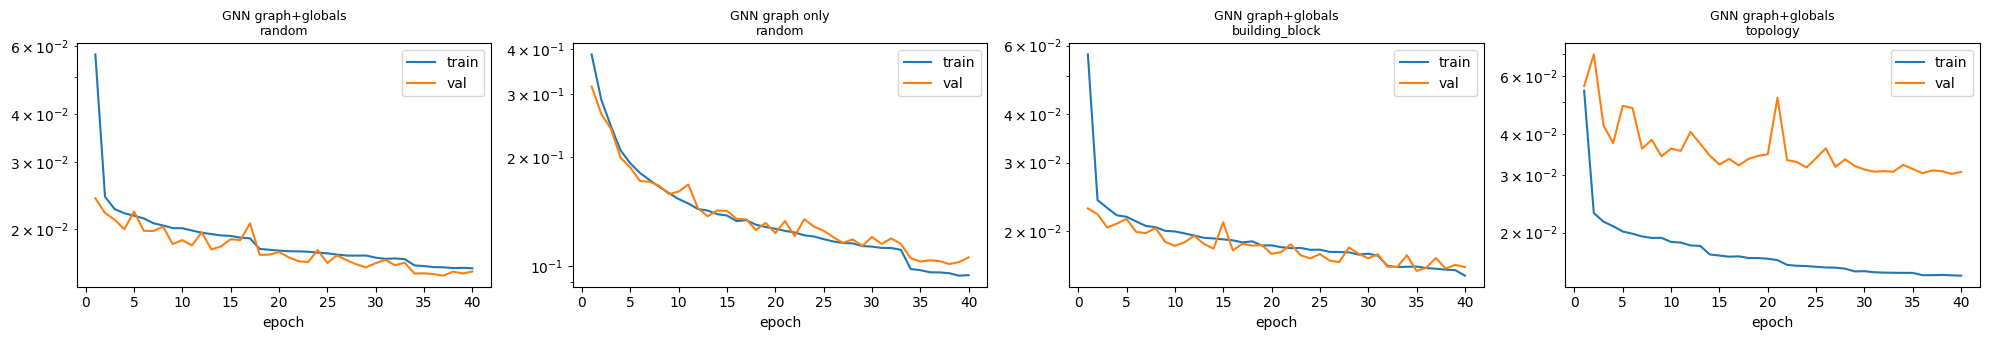

In [41]:
fig, axes = plt.subplots(1, len(HISTORIES), figsize=(5 * len(HISTORIES), 3.5), squeeze=False)
for ax, ((name, split), hist) in zip(axes[0], HISTORIES.items()):
    h = pd.DataFrame(hist)
    ax.plot(h.epoch, h.train, label="train"); ax.plot(h.epoch, h.val, label="val")
    ax.set_yscale("log"); ax.set_title(f"{name}\n{split}", fontsize=9); ax.set_xlabel("epoch"); ax.legend()
savefig("gnn_learning_curves.png")

## 13. Results

In [42]:
res = pd.DataFrame(RESULTS)
res.to_csv(os.path.join(WORK_DIR, "results_all.csv"), index=False)

main = res[(res["eval"] == "end_to_end") & (res.training == "cleaned")]
table = main.pivot_table(index=["split", "model"], columns="target", values=["R2", "MAE", "top5_recall"])
table = table.reindex(columns=pd.MultiIndex.from_product([["R2", "MAE", "top5_recall"], TARGETS]))
print("END-TO-END, CLEANED TEST SET\n")
print(table.round(3).to_string())
table.round(4).to_csv(os.path.join(WORK_DIR, "results_table.csv"))

print("\nEFFECT OF LABEL CLEANING (XGB geometry+composition, random split, cleaned test set)")
print(res[(res.model == "XGB geometry+composition") & (res.split == "random") & (res["eval"] == "end_to_end")]
      .pivot_table(index="training", columns="target", values=["R2", "MAE"]).round(3).to_string())

END-TO-END, CLEANED TEST SET

                                            R2                  MAE               top5_recall              
                                            y2   y100     dc     y2   y100     dc          y2   y100     dc
split          model                                                                                       
building_block GNN graph+globals         0.977  0.989  0.994  0.857  0.989  0.863       0.785  0.779  0.871
               XGB geometry              0.902  0.981  0.973  2.003  1.322  1.858       0.652  0.663  0.682
               XGB geometry+composition  0.980  0.991  0.994  0.812  0.875  0.793       0.798  0.832  0.891
random         GNN graph only            0.843  0.953  0.935  2.321  2.066  2.476       0.647  0.537  0.430
               GNN graph+globals         0.976  0.989  0.994  0.880  0.978  0.854       0.772  0.810  0.871
               XGB geometry              0.900  0.981  0.972  1.998  1.316  1.842       0.662  0.655  0.66

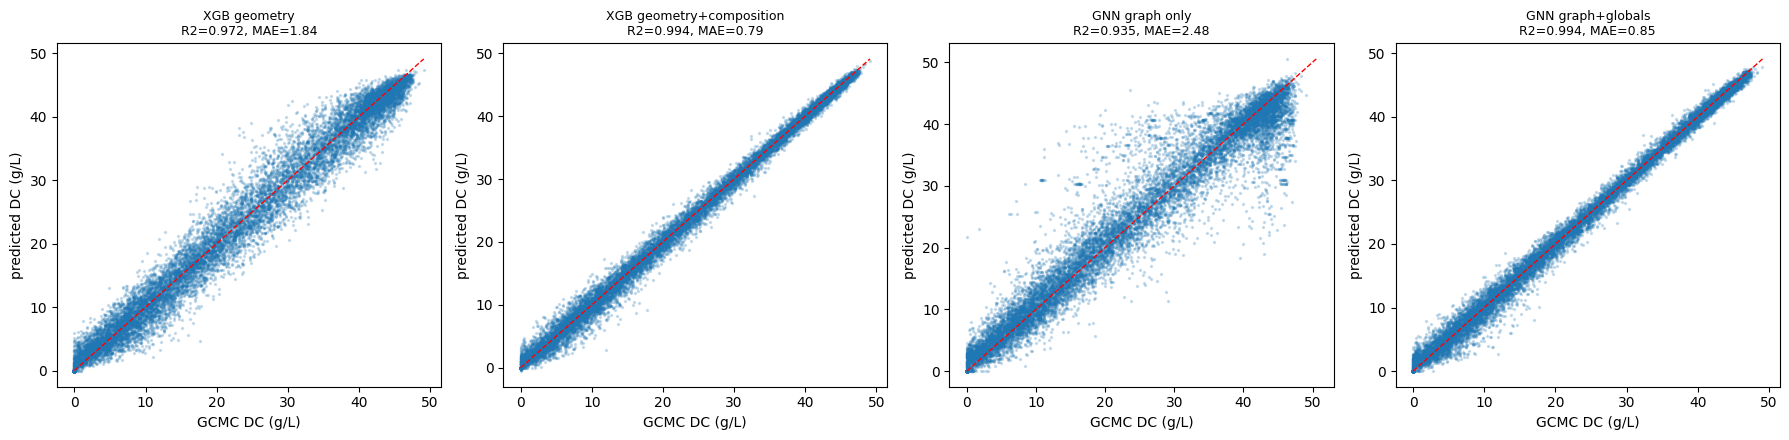

In [43]:
# Parity plots for deliverable capacity on the random split
show = [k for k in [("XGB geometry", "random"), ("XGB geometry+composition", "random"),
                    ("GNN graph only", "random"), ("GNN graph+globals", "random")]
        if k in XGB_PREDS or k in GNN_PREDS]
fig, axes = plt.subplots(1, len(show), figsize=(4.5 * len(show), 4.5), squeeze=False)
for ax, key in zip(axes[0], show):
    p = (XGB_PREDS.get(key) if key in XGB_PREDS else GNN_PREDS[key])["dc"]
    y = df.loc[p.index, "dc"]
    ax.scatter(y, p, s=2, alpha=0.2); lim = [0, max(y.max(), p.max())]
    ax.plot(lim, lim, "r--", lw=1)
    ax.set_title(f"{key[0]}\nR2={r2_score(y, p):.3f}, MAE={mean_absolute_error(y, p):.2f}", fontsize=9)
    ax.set_xlabel("GCMC DC (g/L)"); ax.set_ylabel("predicted DC (g/L)")
savefig("parity_dc_random.png")

## 14. Where do models fail? Error by topology (random split)

In [44]:
key = ("GNN graph+globals", "random") if ("GNN graph+globals", "random") in GNN_PREDS else ("XGB geometry+composition", "random")
p = (GNN_PREDS.get(key) if key in GNN_PREDS else XGB_PREDS[key])
err = df.loc[p.index, ["topology", "dc"]].assign(pred=p["dc"].values)
err["abs_err"] = (err.pred - err.dc).abs()
by_topo = err.groupby("topology").agg(n=("dc", "size"), mean_dc=("dc", "mean"), MAE=("abs_err", "mean")) \
             .sort_values("n", ascending=False)
print(f"Model: {key[0]}")
print(by_topo.round(2).to_string())
by_topo.to_csv(os.path.join(WORK_DIR, "error_by_topology.csv"))

Model: GNN graph+globals
             n  mean_dc   MAE
topology                     
pcu       9602    25.24  0.85
unknown   2341    22.10  0.80
ERROR      646    12.85  1.05
rna        554    14.73  0.99
UNKNOWN    159     4.69  0.87
dia        156    39.60  0.71
hex         86    11.75  0.71
tbo         82    38.80  0.88
sql         66    21.39  0.99
fcu         45     8.10  0.62
bct         10    11.46  0.64
nbo          8    12.76  0.61
cpf          4     2.11  1.03
fse          4     1.91  0.52
bcu          4    22.35  0.60
hcb          4    37.79  0.46
hxl          3     6.19  0.86
fsc          2     7.88  1.83
hms          1    14.12  2.53


## 15. Ensemble uncertainty (random split)

In [45]:
ENS = []
if ("GNN graph+globals", "random") in GNN_PREDS:
    ENS.append(GNN_PREDS[("GNN graph+globals", "random")])
for k in range(N_ENSEMBLE):
    print(f"\n=== Ensemble member seed {SEED + 1 + k} ===")
    model, base, _ = train_gnn("full", "random", seed=SEED + 1 + k)
    te_idx = df.index[rows("random", "test")].tolist()
    pr = gate("random", predict_gnn(model, base, te_idx)); pr[TARGETS] = pr[TARGETS].clip(lower=0.0)
    ENS.append(pr); del model; torch.cuda.empty_cache()

if len(ENS) > 1:
    stack = np.stack([e[TARGETS].values for e in ENS])
    ens_mean = pd.DataFrame(stack.mean(0), index=ENS[0].index, columns=TARGETS)
    ens_std = pd.DataFrame(stack.std(0), index=ENS[0].index, columns=TARGETS)
    record("GNN ensemble", "random", ens_mean)
    abs_err = (ens_mean["dc"] - df.loc[ens_mean.index, "dc"]).abs()
    q = pd.qcut(ens_std["dc"], 5, labels=False, duplicates="drop")
    print("\nDoes uncertainty track error? (DC, quintiles of ensemble std)")
    print(pd.DataFrame({"std": ens_std["dc"], "abs_err": abs_err, "q": q}).groupby("q").mean().round(3).to_string())


=== Ensemble member seed 43 ===
  [full|random|s43] ep 001 train 0.0584 val 0.0240 lr 1.0e-03 1.5 min
  [full|random|s43] ep 005 train 0.0217 val 0.0196 lr 1.0e-03 7.2 min
  [full|random|s43] ep 010 train 0.0200 val 0.0193 lr 1.0e-03 14.4 min
  [full|random|s43] ep 015 train 0.0191 val 0.0205 lr 1.0e-03 21.6 min
  [full|random|s43] ep 020 train 0.0185 val 0.0174 lr 1.0e-03 28.8 min
  [full|random|s43] ep 025 train 0.0169 val 0.0161 lr 5.0e-04 36.1 min
  [full|random|s43] ep 030 train 0.0160 val 0.0155 lr 2.5e-04 43.3 min
  [full|random|s43] ep 035 train 0.0158 val 0.0151 lr 2.5e-04 50.5 min
  [full|random|s43] ep 040 train 0.0156 val 0.0150 lr 2.5e-04 57.7 min
  best val 0.0150 at epoch 40

=== Ensemble member seed 44 ===
  [full|random|s44] ep 001 train 0.0580 val 0.0255 lr 1.0e-03 1.4 min
  [full|random|s44] ep 005 train 0.0218 val 0.0235 lr 1.0e-03 7.2 min
  [full|random|s44] ep 010 train 0.0201 val 0.0186 lr 1.0e-03 14.4 min
  [full|random|s44] ep 015 train 0.0191 val 0.0180 lr 1.

## 16. Export targets for the RASPA notebook

In [46]:
picks = []
f3001 = df[df.flag_floor & (df.id_block == 3001)].sort_values("void_fraction", ascending=False)
picks += [(n, "suspected label error (batch 3001)") for n in f3001.name.head(2)]
other = df[df.flag_floor & (df.id_block != 3001)].sort_values("void_fraction", ascending=False)
picks += [(n, "suspected label error (other batch)") for n in other.name.head(1)]
if len(f3001):
    ref_vf = f3001.void_fraction.iloc[0]
    ctrl = df[(df.id_block == 3001) & ~df.flag & ~df.is_zero].assign(gap=lambda t: (t.void_fraction - ref_vf).abs())
    picks += [(n, "control (same batch, normal label)") for n in ctrl.sort_values("gap").name.head(1)]

if len(ENS) > 1:
    top = ens_mean.assign(std=ens_std["dc"]).sort_values("dc", ascending=False).head(3)
    picks += [(df.loc[i, "name"], "top predicted DC (test set)") for i in top.index]

raspa = pd.DataFrame(picks, columns=["name", "reason"]).merge(
    df[["name", "void_fraction", "lcd", "pld", "y2", "y100", "dc_raw", "topology"]], on="name", how="left")
raspa["cif_path"] = raspa.name.map(cif_index)
if len(ENS) > 1:
    pm = df.loc[ens_mean.index, "name"]
    raspa = raspa.merge(pd.DataFrame({"name": pm.values, "pred_dc": ens_mean["dc"].values,
                                      "pred_dc_std": ens_std["dc"].values}), on="name", how="left")
raspa.to_csv(os.path.join(WORK_DIR, "raspa_targets.csv"), index=False)
print(raspa.to_string(index=False))

        name                              reason  void_fraction   lcd   pld      y2     y100   dc_raw topology                        cif_path   pred_dc  pred_dc_std
hMOF-3001840  suspected label error (batch 3001)       0.905058 22.75 19.75 2.46365  8.64831  6.18466      dia /tmp/hMOF_data/hMOF-3001840.cif       NaN          NaN
hMOF-3001604  suspected label error (batch 3001)       0.904471 22.25 19.25 3.39807  8.11320  4.71513      dia /tmp/hMOF_data/hMOF-3001604.cif       NaN          NaN
hMOF-7001666 suspected label error (other batch)       0.626657  9.25  7.25 7.64004  9.46953  1.82949      hex /tmp/hMOF_data/hMOF-7001666.cif       NaN          NaN
hMOF-3001465  control (same batch, normal label)       0.905135 23.25 20.75 3.28561 43.08990 39.80429  unknown /tmp/hMOF_data/hMOF-3001465.cif       NaN          NaN
hMOF-5033225         top predicted DC (test set)       0.908819 13.75 11.75 6.67227 55.76700 49.09473      pcu /tmp/hMOF_data/hMOF-5033225.cif 47.635166     0.204265
hMOF

## 17. Summary

In [47]:
res = pd.DataFrame(RESULTS)
res.to_csv(os.path.join(WORK_DIR, "results_all.csv"), index=False)
summary = res[(res["eval"] == "end_to_end") & (res.training == "cleaned") & (res.target == "dc")] \
    .set_index(["split", "model"])[["R2", "MAE", "RMSE", "top5_recall", "top5_EF", "top1_recall"]].sort_index()
print("DELIVERABLE CAPACITY (77 K, 100 -> 2 bar), END-TO-END ON THE CLEANED TEST SET\n")
print(summary.round(3).to_string())
print(f"\nFlagged labels removed: {df.flag.sum()} | zero-uptake MOFs: {df.is_zero.sum()} | graphs: {len(graphs)}")
print("All outputs in:", WORK_DIR)

DELIVERABLE CAPACITY (77 K, 100 -> 2 bar), END-TO-END ON THE CLEANED TEST SET

                                            R2    MAE   RMSE  top5_recall  top5_EF  top1_recall
split          model                                                                           
building_block GNN graph+globals         0.994  0.863  1.194        0.871   17.417        0.688
               XGB geometry              0.973  1.858  2.493        0.682   13.643        0.413
               XGB geometry+composition  0.994  0.793  1.126        0.891   17.823        0.754
random         GNN ensemble              0.994  0.828  1.150        0.881   17.620        0.688
               GNN graph only            0.935  2.476  3.799        0.430    8.592        0.203
               GNN graph+globals         0.994  0.854  1.184        0.871   17.417        0.688
               XGB geometry              0.972  1.842  2.489        0.668   13.353        0.514
               XGB geometry+composition  0.994  0.789  1.

In [1]:
# =====================================================================
# SCREENING CELLS: paste each "CELL" into a new cell at the END of the
# modelling notebook, in order. They reuse variables from that notebook
# (df, graphs, comp_df, FEATS_GEO, FEATS_GEO_COMP, STAGE1, XGB_PARAMS,
#  MOFNet, element_features, composition_descriptors, WORK_DIR, ...).
# If your session restarted, rerun Sections 1-9 first (graphs load from
# the cache, so this takes minutes, not hours).
# =====================================================================


# %% CELL 1 -- Sanity check + RASPA settings used for the hMOF labels
needed = ["df", "graphs", "comp_df", "FEATS_GEO", "FEATS_GEO_COMP", "STAGE1", "XGB_PARAMS",
          "MOFNet", "element_features", "composition_descriptors", "json_index", "cif_index"]
missing = [v for v in needed if v not in globals()]
assert not missing, f"Rerun the earlier sections first; missing: {missing}"
print(f"OK: df {len(df)} rows, {len(graphs)} graphs")

with open(json_index[df.name.iloc[0]]) as f:
    d0 = json.load(f)
iso0 = d0["isotherms"][0]
print("Isotherm keys:", list(iso0.keys()))
for k in ("simin", "simulation_input", "doi", "category", "adsorbent_forcefield", "molecule_forcefield"):
    if k in iso0:
        v = iso0[k]
        print(f"\n--- {k} ---\n{v[:4000] if isinstance(v, str) else v}")
if isinstance(iso0.get("simin"), str):
    with open(os.path.join(WORK_DIR, "raspa_reference_simin.txt"), "w") as f:
        f.write(iso0["simin"])
    print("\nSaved the reference RASPA input to raspa_reference_simin.txt")


# %% CELL 2 -- Install Zeo++ (pore descriptors)
import shutil
ZEO = shutil.which("network")
if ZEO is None:
    os.chdir("/tmp")
    r = subprocess.run("wget -q -O zeo.tar.gz http://www.zeoplusplus.org/zeo++-0.3.tar.gz && "
                       "tar xzf zeo.tar.gz && cd zeo++-0.3/voro++/src && make -s && cd ../.. && make -s",
                       shell=True, capture_output=True, text=True)
    ZEO = "/tmp/zeo++-0.3/network" if os.path.exists("/tmp/zeo++-0.3/network") else None
    if ZEO is None:
        print("Source build failed, trying conda...\n", r.stderr[-1500:])
        subprocess.run("conda install -y -q -c conda-forge zeopp-lsmo", shell=True)
        ZEO = shutil.which("network")
    os.chdir("/kaggle/working" if os.path.isdir("/kaggle/working") else os.path.expanduser("~"))
assert ZEO, "Zeo++ could not be installed"
print("Zeo++ binary:", ZEO)


# %% CELL 3 -- Zeo++ runner (writes a clean P1 CIF with pymatgen first)
import re, tempfile
from pymatgen.io.cif import CifWriter

KV = re.compile(r"(\S+):\s+([-+\d.eE]+)")
VOL_PROBES = (0.0, 1.2)        # geometric and probe-accessible void fraction; calibration picks the best

def zeo_descriptors(cif_path):
    warnings.filterwarnings("ignore")
    try:
        s = Structure.from_file(cif_path)
        with tempfile.TemporaryDirectory() as tmp:
            cif = os.path.join(tmp, "s.cif")
            CifWriter(s).write_file(cif)
            out = {"density_pmg": s.density}
            subprocess.run([ZEO, "-ha", "-res", f"{tmp}/s.res", cif], capture_output=True, timeout=600)
            tok = open(f"{tmp}/s.res").read().split()
            out["lcd_zeo"], out["pld_zeo"] = float(tok[1]), float(tok[2])
            subprocess.run([ZEO, "-ha", "-sa", "1.86", "1.86", "2000", f"{tmp}/s.sa", cif],
                           capture_output=True, timeout=600)
            kv = dict(KV.findall(open(f"{tmp}/s.sa").readline()))
            out["sa_m2g_zeo"], out["sa_m2cm3_zeo"] = float(kv["ASA_m^2/g"]), float(kv["ASA_m^2/cm^3"])
            for p in VOL_PROBES:
                subprocess.run([ZEO, "-ha", "-vol", str(p), str(p), "50000", f"{tmp}/s.vol", cif],
                               capture_output=True, timeout=600)
                kv = dict(KV.findall(open(f"{tmp}/s.vol").readline()))
                out[f"vf_zeo_{p}"] = float(kv["AV_Volume_fraction"])
            return out
    except Exception as e:
        return {"error": str(e)[:100]}

test = zeo_descriptors(cif_index[df.name.iloc[0]])
print("Test MOF:", df.name.iloc[0], test)
print("JSON values:", df.loc[0, GEO].to_dict())


# %% CELL 4 -- Calibrate Zeo++ against the hMOF JSON descriptors (300 MOFs)
# Fix: volumetric surface area = calibrated gravimetric SA x density (as in the hMOF JSON)
def apply_calibration(z):
    out = {}
    for target, (src, a, b) in CALIB.items():
        out[target] = a * z[src] + b if pd.notna(z.get(src)) else np.nan
    out["density"] = z["density_pmg"]
    out["surface_area_m2cm3"] = out["surface_area_m2g"] * out["density"]
    return out

# Robustness test: same MOFs, JSON descriptors vs calibrated Zeo++ descriptors
tr = rows("random", "train") & ~df.is_zero
va = rows("random", "val") & ~df.is_zero
xgb_dc = xgb.XGBRegressor(**XGB_PARAMS)
xgb_dc.fit(X_all.loc[tr, FEATS_GEO_COMP], df.loc[tr, "dc"],
           eval_set=[(X_all.loc[va, FEATS_GEO_COMP], df.loc[va, "dc"])], verbose=False)

idx = df.set_index("name").loc[cal.index].index
rows_idx = df.index[df.name.isin(cal.index)]
X_json = X_all.loc[rows_idx, FEATS_GEO_COMP].copy()
X_zeo = X_json.copy()
zeo_vals = pd.DataFrame([apply_calibration(cal.loc[n]) for n in df.loc[rows_idx, "name"]], index=rows_idx)
for c in GLOBALS:
    X_zeo[c] = zeo_vals[c]

p_json, p_zeo = xgb_dc.predict(X_json), xgb_dc.predict(X_zeo)
y_true = df.loc[rows_idx, "dc"].values
print(f"DC prediction shift (JSON vs Zeo++ inputs): MAE = {np.abs(p_json - p_zeo).mean():.2f} g/L, "
      f"Spearman = {pd.Series(p_json).corr(pd.Series(p_zeo), method='spearman'):.3f}")
print(f"Error vs GCMC: JSON inputs MAE = {np.abs(p_json - y_true).mean():.2f} | "
      f"Zeo++ inputs MAE = {np.abs(p_zeo - y_true).mean():.2f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(cal["pld_zeo"], cal["pld"], s=6); ax[0].set_xlabel("PLD Zeo++"); ax[0].set_ylabel("PLD hMOF JSON")
ax[1].scatter(cal["vf_zeo_0.0"], cal["void_fraction"], s=6); ax[1].set_xlabel("VF Zeo++ (geometric)"); ax[1].set_ylabel("VF hMOF JSON")
for a in ax: a.plot([0, a.get_xlim()[1]], [0, a.get_xlim()[1]], "r--", lw=1)
savefig("zeo_vs_json_pld_vf.png")

# %% CELL 5 -- Download CoRE MOF 2024 (public SI subset, computation-ready)
CORE_DIR = "/tmp/coremof"
CORE_ZIP = "/tmp/CoREMOF2024DB_SI.zip"
CORE_URL = "https://zenodo.org/records/15055758/files/CoREMOF2024DB_SI_20250204.zip?download=1"
if not os.path.isdir(CORE_DIR):
    subprocess.run(["wget", "-q", "-O", CORE_ZIP, CORE_URL], check=True)
    with zipfile.ZipFile(CORE_ZIP) as z:
        z.extractall(CORE_DIR)

all_cifs = [os.path.join(dp, f) for dp, _, fs in os.walk(CORE_DIR) for f in fs if f.lower().endswith(".cif")]
print("Total CIFs:", len(all_cifs))
print("Folder structure (CIF counts):")
print(pd.Series([os.path.relpath(os.path.dirname(p), CORE_DIR) for p in all_cifs]).value_counts().to_string())


# %% CELL 6 -- Keep computation-ready structures, prefer ASR over FSR for duplicates
def subset_of(path):
    p = path.replace("\\", "/").upper()
    cr = ("/CR/" in p or "/CR_" in p or p.split("/")[-2].startswith("CR")) and "NCR" not in p
    kind = "ASR" if "ASR" in p else "FSR" if "FSR" in p else "ION" if "ION" in p else "?"
    return cr, kind

core = pd.DataFrame({"path": all_cifs})
core[["cr", "kind"]] = pd.DataFrame([subset_of(p) for p in core.path], index=core.index)
core["stem"] = core.path.map(lambda p: os.path.splitext(os.path.basename(p))[0])
print(core.groupby(["cr", "kind"]).size().to_string())

core = core[core.cr & core.kind.isin(["ASR", "FSR"])].copy()
core["rank"] = core.kind.map({"ASR": 0, "FSR": 1})
core["base"] = core.stem.str.replace(r"_(ASR|FSR|asr|fsr).*$", "", regex=True)
core = core.sort_values(["base", "rank"]).drop_duplicates("base").reset_index(drop=True)
print(f"\nUnique computation-ready MOFs to screen: {len(core)}")
assert len(core) > 0, "No CR files matched: send me the folder structure printed in CELL 5"


# %% CELL 7 -- Featurize CoRE MOFs: graph + Zeo++ descriptors (calibrated)
def featurize_path(path):
    warnings.filterwarnings("ignore")
    try:
        s = Structure.from_file(path)
        if len(s) > MAX_ATOMS:
            return None
        x = [list(element_features(site.specie.symbol)) for site in s]
        edges, dists, degree = [], [], [0] * len(s)
        for i, nlist in enumerate(s.get_all_neighbors(r=NEIGHBOR_CUTOFF)):
            for n in nlist:
                edges.append([i, n.index]); dists.append([float(n.nn_distance)]); degree[i] += 1
        if not edges:
            return None
        for i in range(len(x)):
            x[i].append(float(degree[i]))
        z = zeo_descriptors(path)
        if "error" in z:
            return None
        return x, edges, dists, z
    except Exception:
        return None

MAX_ATOMS = int(np.percentile([g.x.shape[0] for g in random.Random(SEED).sample(list(graphs.values()), 5000)], 99.5))
print("Skipping CoRE MOFs larger than", MAX_ATOMS, "atoms (outside the hMOF training range)")

with Pool(cpu_count()) as pool:
    feats = list(tqdm(pool.imap(featurize_path, core.path, chunksize=4), total=len(core)))

core_graphs, desc_rows = [], []
for k, r in enumerate(feats):
    if r is None:
        continue
    x, edges, dists, z = r
    cal_vals = apply_calibration(z)
    cal_vals["density"] = z["density_pmg"]
    g = Data(x=torch.tensor(x, dtype=torch.float),
             edge_index=torch.tensor(edges, dtype=torch.long).t().contiguous(),
             edge_attr=torch.tensor(dists, dtype=torch.float))
    g.idx = len(core_graphs)
    g.gfeat = torch.tensor([[cal_vals[c] for c in GLOBALS]], dtype=torch.float)
    g.y = torch.zeros(1, len(TARGETS))
    core_graphs.append(g)
    desc_rows.append({"core_row": k, **cal_vals, **{f"raw_{kk}": vv for kk, vv in z.items()}})

cdf = pd.DataFrame(desc_rows)
cdf["name"] = core.loc[cdf.core_row, "stem"].values
cdf["path"] = core.loc[cdf.core_row, "path"].values
print(f"Featurized {len(cdf)} of {len(core)} CoRE MOFs")
cdf.to_csv(os.path.join(WORK_DIR, "core_descriptors.csv"), index=False)


# %% CELL 8 -- Applicability domain (elements, descriptor ranges, size)
train_mask = df.usable & ~df.flag
seen_Z = {int(c.replace("frac_Z", "")) for c in comp_df.columns if c.startswith("frac_Z")
          and (comp_df.loc[train_mask, c] > 0).any()}
lo = df.loc[train_mask, GLOBALS].quantile(0.005)
hi = df.loc[train_mask, GLOBALS].quantile(0.995)

def domain_check(i):
    g = core_graphs[i]
    zs = set(g.x[:, 0].int().tolist())
    unseen = sorted(zs - seen_Z)
    row = cdf.iloc[i]
    out_range = [c for c in GLOBALS if not (lo[c] <= row[c] <= hi[c])]
    return unseen, out_range

checks = [domain_check(i) for i in range(len(cdf))]
cdf["unseen_elements"] = [",".join(map(str, u)) for u, _ in checks]
cdf["out_of_range"] = [",".join(o) for _, o in checks]
cdf["in_domain"] = [(not u) and (not o) for u, o in checks]
print(f"In domain: {cdf.in_domain.sum()} / {len(cdf)}")
print("Most common unseen elements (Z):",
      pd.Series([z for u, _ in checks for z in u]).value_counts().head(10).to_dict())
print("Most common out-of-range descriptors:",
      pd.Series([c for _, o in checks for c in o]).value_counts().to_dict())


# %% CELL 9 -- Predict with XGBoost (geometry + composition) and the GNN ensemble
# 9a. Composition features for CoRE (same columns as training)
comp_core = np.stack([composition_descriptors(g) for g in core_graphs])
comp_core = pd.DataFrame(comp_core, columns=comp_names)[list(comp_df.columns)]
X_core = pd.concat([cdf[FEATS_GEO].reset_index(drop=True), comp_core], axis=1)[FEATS_GEO_COMP]

# 9b. Stage 1 (zero / non-zero) and XGBoost regressors refit on the random-split training data
cdf["p_zero"] = STAGE1["random"].predict_proba(cdf[FEATS_GEO])[:, 1]
tr = rows("random", "train") & ~df.is_zero
va = rows("random", "val") & ~df.is_zero
for t in TARGETS:
    m = xgb.XGBRegressor(**XGB_PARAMS)
    m.fit(X_all.loc[tr, FEATS_GEO_COMP], df.loc[tr, t],
          eval_set=[(X_all.loc[va, FEATS_GEO_COMP], df.loc[va, t])], verbose=False)
    cdf[f"xgb_{t}"] = np.clip(m.predict(X_core), 0, None)

# 9c. GNN ensemble from the saved checkpoints
ckpts = sorted(glob.glob(os.path.join(WORK_DIR, "gnn_full_random_s*.pth")))
print("GNN checkpoints:", [os.path.basename(c) for c in ckpts])
core_loader = DataLoader(core_graphs, batch_size=64, shuffle=False)
ens = []
for c in ckpts:
    net = MOFNet().to(DEVICE)
    net.load_state_dict(torch.load(c, map_location=DEVICE, weights_only=True))
    net.eval(); outs = []
    with torch.no_grad():
        for b in core_loader:
            b = b.to(DEVICE)
            outs.append((net(b) * net.y_sd + net.y_mu).cpu())
    ens.append(torch.cat(outs).numpy())
ens = np.clip(np.stack(ens), 0, None)
for j, t in enumerate(TARGETS):
    cdf[f"gnn_{t}"] = ens[:, :, j].mean(0)
    cdf[f"gnn_{t}_std"] = ens[:, :, j].std(0)

# 9d. Gate non-porous frameworks to zero
zero = cdf.p_zero > 0.5
for t in TARGETS:
    cdf.loc[zero, [f"xgb_{t}", f"gnn_{t}"]] = 0.0
print(f"Predicted non-porous: {zero.sum()}")
print("Agreement XGB vs GNN on DC (Spearman):",
      round(cdf.xgb_dc.corr(cdf.gnn_dc, method="spearman"), 3))


# %% CELL 10 -- Rank and choose the top 10 for RASPA
cdf["consensus_dc"] = (cdf.xgb_dc + cdf.gnn_dc) / 2
cdf["model_gap_dc"] = (cdf.xgb_dc - cdf.gnn_dc).abs()
cand = cdf[cdf.in_domain & (cdf.p_zero < 0.5)].sort_values("consensus_dc", ascending=False)

cols = ["name", "consensus_dc", "xgb_dc", "gnn_dc", "gnn_dc_std", "model_gap_dc",
        "xgb_y100", "gnn_y100", "xgb_y2", "gnn_y2", "void_fraction", "lcd", "pld", "surface_area_m2g", "density"]
print("TOP 20 IN-DOMAIN CANDIDATES (deliverable capacity, 77 K, 100 -> 2 bar, g/L)")
print(cand[cols].head(20).round(2).to_string(index=False))

# Best 10, skipping candidates where the two models disagree strongly
top10 = cand[cand.model_gap_dc < 3.0].head(10)
cdf.sort_values("consensus_dc", ascending=False).to_csv(os.path.join(WORK_DIR, "core_screening_all.csv"), index=False)
top10.to_csv(os.path.join(WORK_DIR, "core_top10.csv"), index=False)

print("\nOut-of-domain MOFs with the highest predictions (reported separately, not verified):")
print(cdf[~cdf.in_domain].sort_values("consensus_dc", ascending=False)
      [["name", "consensus_dc", "unseen_elements", "out_of_range"]].head(10).to_string(index=False))


# %% CELL 11 -- Package everything for the RASPA notebook
RASPA_DIR = os.path.join(WORK_DIR, "raspa_inputs")
for sub in ("core_top10", "hmof"):
    os.makedirs(os.path.join(RASPA_DIR, sub), exist_ok=True)
for _, r in top10.iterrows():
    shutil.copy(r.path, os.path.join(RASPA_DIR, "core_top10", r["name"] + ".cif"))

hm = pd.read_csv(os.path.join(WORK_DIR, "raspa_targets.csv"))
hm = hm[~hm.reason.str.startswith("top predicted")]            # controls + suspected label errors
extra_ctrl = df[~df.flag & ~df.is_zero & (df.id_block != 3001)].sample(2, random_state=SEED)
hm = pd.concat([hm, pd.DataFrame({"name": extra_ctrl.name, "reason": "control (random normal hMOF)",
                                  "y2": extra_ctrl.y2, "y100": extra_ctrl.y100})], ignore_index=True)
for n in hm.name:
    shutil.copy(cif_index[n], os.path.join(RASPA_DIR, "hmof", n + ".cif"))
hm.to_csv(os.path.join(RASPA_DIR, "hmof_targets.csv"), index=False)
top10.to_csv(os.path.join(RASPA_DIR, "core_top10.csv"), index=False)
for f in ("raspa_reference_simin.txt", "zeo_calibration.csv"):
    if os.path.exists(os.path.join(WORK_DIR, f)):
        shutil.copy(os.path.join(WORK_DIR, f), RASPA_DIR)

shutil.make_archive(os.path.join(WORK_DIR, "raspa_inputs"), "zip", RASPA_DIR)
print("hMOF structures:", len(hm), "| CoRE top-10:", len(top10))
print("Packed:", os.path.join(WORK_DIR, "raspa_inputs.zip"), "-> download it or Save Version")

AssertionError: Rerun the earlier sections first; missing: ['df', 'graphs', 'comp_df', 'FEATS_GEO', 'FEATS_GEO_COMP', 'STAGE1', 'XGB_PARAMS', 'MOFNet', 'element_features', 'composition_descriptors', 'json_index', 'cif_index']